# 16장 실습 — 배포 게이트

여기까지의 열다섯 장은 **한 대의 로봇 안**을 다뤘다. 이 장부터는 그 정책이 **여러 대에 배포되고 다시 돌아오는** 과정을 본다.

배포에는 문 하나가 있다. **이 새 버전을 내보낼 것인가.** 그 문을 사람의 눈대중이 아니라 규칙으로 만드는 것이 회귀 게이트다.

정직하게 적을 것이 있다. **벤더가 이 문의 설계를 주지 않는다.** NVIDIA Fleet Command 의 공개 FAQ 에는 OTA 주장도, 규모 수치도, 텔레메트리 명세도 없다. 그러니 게이트는 직접 설계해야 하고, 이 노트북은 그 설계를 세 가지로 시험한다 — **어느 조건에서 재는가**, **몇 판을 보는가**, **무엇을 통과 기준으로 삼는가.**

실행 시간은 CPU에서 9분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (224s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 로그 스키마부터

게이트를 설계하기 전에 **무엇을 기록할지** 정해야 한다. 판마다 한 줄이고, 그 줄에 3장·14장·15장이 요구한 항목이 모두 들어간다.

| 열 | 뜻 |
|---|---|
| version | 정책 버전 |
| cond | 평가 조건 (명목 / 배포) |
| ep | 판 번호 |
| success | 성공 여부 |
| viol | 경계 이탈 여부 |
| mm | 경계 밖으로 나간 최대 거리 |

지연은 판마다가 아니라 스텝마다 재야 하므로 별도 표에 둔다. 여기서는 **성공률과 안전**만으로 게이트를 만든다.

In [6]:
LIM = np.array([.36, .115])


def pusher_xy(env):
    return np.array([d.qpos[7:9] for d in env.d])


def excess(p):
    return np.maximum(np.abs(p) - LIM[None, :], 0.).max(axis=1)


def rollout(policy, cond, n=150, reps=8, seed=7):
    """판마다 한 줄 — 배포 로그의 스키마"""
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    worst = np.zeros(n)
    rows = []
    for t in range(EP * reps):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = policy.dist(ot).sample().numpy()
        _, dn, sc = env.step(a)
        worst = np.maximum(worst, excess(pusher_xy(env)))
        j = 0
        for i in range(n):
            if dn[i]:
                rows.append((int(sc[j] > .5), worst[i] * 1000.))
                worst[i] = 0.
                j += 1
    r = np.array(rows)
    return dict(success=r[:, 0].astype(int), mm=r[:, 1])


print("한 줄 = 한 판")
print("열 — version · cond · ep · success · viol · mm")

한 줄 = 한 판
열 — version · cond · ep · success · viol · mm


## 네 후보

배포 문 앞에 설 후보를 넷 만든다. 학습을 다시 하지 않고, 5장의 가짜 양자화로 **버전 차이를 흉내 낸다.** 실기에서 이 넷은 각각 「현행」, 「가벼운 최적화」, 「무리한 최적화」, 「잘못된 미세조정」에 해당한다.

In [7]:
def fq(w, bits):
    qmax = 2 ** (bits - 1) - 1
    s = w.abs().amax(dim=1, keepdim=True) / qmax
    s = torch.clamp(s, min=1e-12)
    return torch.clamp(torch.round(w / s), -qmax - 1, qmax) * s


def quantized(net, bits):
    q = copy.deepcopy(net)
    with torch.no_grad():
        for m in q.pi.modules():
            if isinstance(m, nn.Linear):
                m.weight.copy_(fq(m.weight, bits))
    return q


def noised(net, sd=.03, seed=3):
    g = torch.Generator().manual_seed(seed)
    q = copy.deepcopy(net)
    with torch.no_grad():
        for m in q.pi.modules():
            if isinstance(m, nn.Linear):
                m.weight.add_(torch.randn(m.weight.shape,
                                          generator=g) * sd)
    return q


CAND = {"v0 현행": POLICY,
        "v1 8비트": quantized(POLICY, 8),
        "v2 3비트": quantized(POLICY, 3),
        "v3 잡음": noised(POLICY)}
print("후보:", " · ".join(CAND))

후보: v0 현행 · v1 8비트 · v2 3비트 · v3 잡음


In [8]:
t0 = time.time()
LOG = {(k, c): rollout(p, c)
       for k, p in CAND.items() for c in COND}
print(f"롤아웃 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("후보", 12) + pad("명목 성공", 12, True)
      + pad("배포 성공", 12, True) + pad("배포 이탈 p99", 15, True))
for k in CAND:
    a, b = LOG[(k, "명목")], LOG[(k, "배포")]
    print(pad(k, 12) + pad(f"{a['success'].mean():.3f}", 12, True)
          + pad(f"{b['success'].mean():.3f}", 12, True)
          + pad(f"{np.percentile(b['mm'], 99):.0f} mm", 15, True))
print()
NEP = len(LOG[("v0 현행", "명목")]["success"])
print(f"후보·조건마다 {NEP} 판")

롤아웃 끝  (306s)

후보           명목 성공   배포 성공  배포 이탈 p99
v0 현행            0.892       0.743         321 mm
v1 8비트           0.905       0.738         253 mm
v2 3비트           0.923       0.246         284 mm
v3 잡음            0.922       0.878         170 mm

후보·조건마다 1200 판


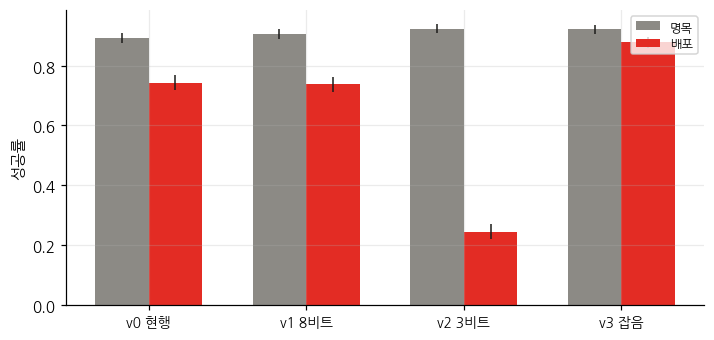

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ks = list(CAND)
x = np.arange(len(ks))
w = .34
for i, (c, col) in enumerate((("명목", GREY), ("배포", RED))):
    v = [LOG[(k, c)]["success"].mean() for k in ks]
    e = [1.96 * (p * (1 - p) / len(LOG[(k, c)]["success"])) ** .5
         for k, p in zip(ks, v)]
    ax.bar(x + (i - .5) * w, v, w, yerr=e, color=col, label=c,
           error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=9)
ax.set_ylabel("성공률")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 게이트 규칙을 적는다

규칙은 3장·14장의 규약을 따른다. 후보에서 N 판, 현행에서 N 판을 보고 **후보의 성공률 95% Wilson 하한이 현행의 점추정에서 여유 m 을 뺀 값 이상이면 통과**다.

여유 m 이 0 이면 「현행보다 확실히 나아야 통과」라는 뜻이 된다. 같은 성능의 후보도 막히는데, 하한은 언제나 점추정보다 낮기 때문이다. m 을 키우면 동등한 후보가 통과하는 대신 조금 나쁜 후보도 새어 나간다.

위에서 모아 둔 판에서 N 판씩 다시 뽑아(부트스트랩) 게이트를 1,000번 돌리면 이 맞바꿈을 직접 셀 수 있다.

In [10]:
def gate(cand, base, n, rng, margin=0.):
    """N 판씩 뽑아 Wilson 하한으로 판정한다"""
    a = rng.choice(cand, n)
    b = rng.choice(base, n)
    lo, _ = wilson(a.sum(), n)
    return lo >= b.mean() - margin


RNG = np.random.default_rng(0)
TRIALS = 1000
NS = (30, 100, 300, 1000)
KS = ("v1 8비트", "v2 3비트", "v3 잡음")


def sweep(cond, margin):
    base = LOG[("v0 현행", cond)]["success"]
    print(f"[{cond} 조건 · 여유 {margin:.2f}]")
    print(pad("N", 7) + "".join(pad(k, 11, True) for k in KS))
    for n in NS:
        row = pad(f"{n}", 7)
        for k in KS:
            s = LOG[(k, cond)]["success"]
            r = np.mean([gate(s, base, n, RNG, margin)
                         for _ in range(TRIALS)])
            row += pad(f"{r:.2f}", 11, True)
        print(row)
    print()


sweep("명목", 0.)
sweep("배포", 0.)

[명목 조건 · 여유 0.00]
N         v1 8비트   v2 3비트    v3 잡음


30            0.04       0.07       0.07
100           0.12       0.21       0.19


300           0.15       0.40       0.40


1000          0.31       0.84       0.78

[배포 조건 · 여유 0.00]
N         v1 8비트   v2 3비트    v3 잡음
30            0.06       0.00       0.45


100           0.06       0.00       0.85


300           0.06       0.00       1.00


1000          0.05       0.00       1.00



## 판 수를 늘리면 틀린 결론이 더 확실해진다

명목 표를 세로로 읽는다. N 이 30 에서 1,000 으로 가면 **v2 3비트의 통과율이 0.07 에서 0.84 로 오른다.** 판 수를 늘릴수록 게이트가 최악의 후보를 더 확실하게 내보낸다.

표본을 늘리는 것은 **잡음을 줄이는 일**이지 **편향을 고치는 일**이 아니다. 명목 조건에서 3비트가 실제로 조금 더 높으므로, 판을 많이 볼수록 그 사실이 또렷해진다. 틀린 자로 오래 재면 틀린 값이 정밀해진다.

배포 표는 반대다. v2 는 어느 N 에서도 **0.00** 이고, 실제로 나은 v3 은 N=300 부터 **1.00** 이다.

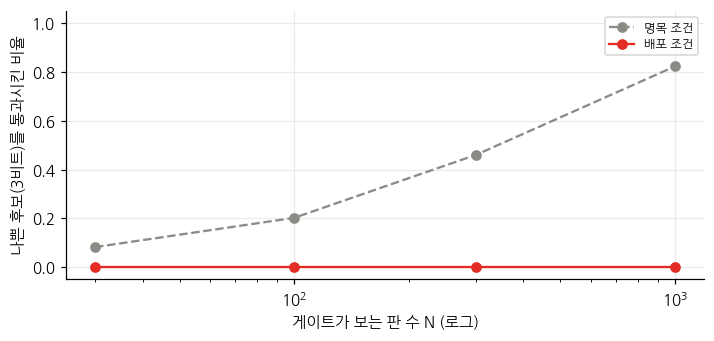

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
for c, col, ls in (("명목", GREY, "--"), ("배포", RED, "-")):
    base = LOG[("v0 현행", c)]["success"]
    s = LOG[("v2 3비트", c)]["success"]
    y = [np.mean([gate(s, base, n, RNG) for _ in range(TRIALS)])
         for n in NS]
    ax.plot(NS, y, ls, color=col, marker="o", label=f"{c} 조건")
ax.set_xscale("log")
ax.set_xlabel("게이트가 보는 판 수 N (로그)")
ax.set_ylabel("나쁜 후보(3비트)를 통과시킨 비율")
ax.set_ylim(-.05, 1.05)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 여유를 준다

배포 조건 · 여유 0 의 표에는 다른 문제가 있다. **v1 8비트가 어느 N 에서도 0.06 밖에 통과하지 못한다.** 현행과 같은 정책인데 막힌다.

실기에서 이것은 사소한 문제가 아니다. 성능이 같고 메모리가 4분의 1 인 버전을 내보내지 못한다는 뜻이다. 여유를 주면 어떻게 되는지 본다.

In [12]:
for m in (.02, .05):
    sweep("배포", m)

[배포 조건 · 여유 0.02]
N         v1 8비트   v2 3비트    v3 잡음
30            0.07       0.00       0.46
100           0.13       0.00       0.90


300           0.17       0.00       1.00
1000          0.25       0.00       1.00

[배포 조건 · 여유 0.05]
N         v1 8비트   v2 3비트    v3 잡음
30            0.14       0.00       0.62


100           0.24       0.00       0.96
300           0.42       0.00       1.00


1000          0.80       0.00       1.00



## 안전 열은 따로 본다

성공률 하나로 문을 여닫으면 15장에서 만든 안전 열이 버려진다. 게이트에 두 번째 조건을 건다 — **경계 이탈 p99 가 현행보다 10% 넘게 나빠지면 성공률과 무관하게 막는다.**

In [13]:
MARGIN = .05
b = LOG[("v0 현행", "배포")]
b_ok, b_mm = b["success"].mean(), np.percentile(b["mm"], 99)
print(pad("후보", 12) + pad("성공 하한", 12, True)
      + pad("성공 판정", 11, True) + pad("이탈 p99", 11, True)
      + pad("최종", 9, True))
for k in CAND:
    r = LOG[(k, "배포")]
    lo, _ = wilson(r["success"].sum(), len(r["success"]))
    mm = np.percentile(r["mm"], 99)
    p1 = lo >= b_ok - MARGIN
    p2 = mm <= b_mm * 1.1
    print(pad(k, 12) + pad(f"{lo:.3f}", 12, True)
          + pad("통과" if p1 else "막음", 11, True)
          + pad(f"{mm:.0f} mm", 11, True)
          + pad("통과" if (p1 and p2) else "막음", 9, True))
print()
print(f"현행 기준 — 성공 {b_ok:.3f} · 이탈 p99 {b_mm:.0f} mm"
      f" · 여유 {MARGIN:.2f}")

후보           성공 하한  성공 판정   이탈 p99     최종
v0 현행            0.718       통과     321 mm     통과
v1 8비트           0.712       통과     253 mm     통과
v2 3비트           0.222       막음     284 mm     막음
v3 잡음            0.859       통과     170 mm     통과

현행 기준 — 성공 0.743 · 이탈 p99 321 mm · 여유 0.05


## 정리

**로그 스키마가 게이트보다 먼저다.** 판마다 성공·이탈·거리를 적어 두지 않으면 나중에 어떤 게이트도 만들 수 없다.

**어느 조건에서 재는지가 판 수보다 중요하다.** 명목 조건에서 3비트는 넷 중 가장 높은 성적을 냈고, 판 수를 30 에서 1,000 으로 늘리자 통과율이 0.07 에서 0.84 로 올랐다. **표본을 늘리는 것은 잡음을 줄이는 일이지 편향을 고치는 일이 아니다.**

**어느 후보가 나쁜지는 미리 알 수 없다.** 가중치에 잡음을 준 버전이 배포 조건에서 현행보다 나았다. 이름이 아니라 수가 판정해야 한다.

**여유와 N 은 허용 오판에서 거꾸로 정한다.** 여유 0 은 현행과 같은 8비트 버전을 94% 확률로 막았고, 여유 0.05 에 N=1,000 이면 80% 통과시키면서도 3비트는 여전히 0.00 이었다. 여유는 「몇 포인트 나쁜 버전까지 허용하는가」를 숫자로 적는 자리다.

**안전 열은 성공률과 따로 판정한다.** 성공률이 같아도 이탈이 커진 버전은 막아야 한다.

다음 장은 문을 통과한 뒤의 이야기다. 현장에서 돌아온 데이터가 **정말 정책을 고치는가.**